# Visualize agent performance
In order to run this notebook, evaluate an agent on an environment (see [[../baselines/baseline_agent.py]]).

In [4]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent.parent  # Adjusts for notebook being in src/visualization/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [5]:
from pathlib import Path

from src.common.constants import EVAL_PATH
from src.visualization import get_evaluation_metrics, visualize_agent_survival, \
    visualize_agent_survival_return_relationship, visualize_performance_vs_prior

# Compare agent survival on test sets

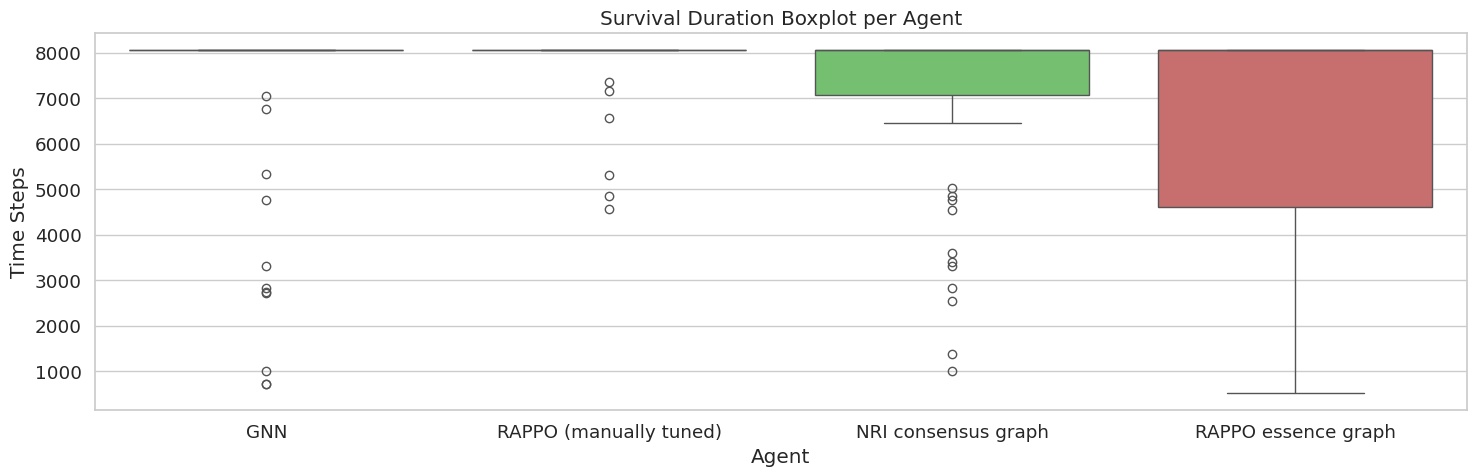

In [7]:


ppo_gnn_metrics = get_evaluation_metrics(Path("/home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/results/experiments/1001_compare_all/GNN_CustomPPO_0_47ac9_2026-01-09_19-01-53/evaluations"), "GNN")
ppo_mlp_metrics = get_evaluation_metrics(Path("/home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/results/experiments/1001_compare_all/MLP_CustomPPO_0_98de8_2026-01-09_19-04-10/evaluations"), "MLP (now)")
# ppo_nri_gnn_metrics = get_evaluation_metrics(Path("/home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/results/experiments/1001_compare_all/NRI_GNN_CustomPPO_0_b4e4e_2026-01-09_19-55-03/evaluations"), "NRI-GNN")
ppo_ra_gnn_metrics = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1801_rappo_with_anneal_different_betas/CustomPPO_0_5448b_2026-01-18_14-26-43/evaluations/"), "RA-GNN")
#ppo_ra_gnn_low_beta_metrics = get_evaluation_metrics(Path("/home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/results/experiments/1201_ragnn_prior1_high_beta_temp0_like_gnn/CustomPPO_0_420a7_2026-01-12_13-21-44/evaluations"), "GNN-like")
old_ppo_performance = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/improve_baseline/evaluations/baselines/ppo/mlp_2025-12-13_17-39-58_510/checkpoints/checkpoint_100000/agent/val/"), "MLP (previously)")
reco = get_evaluation_metrics(Path("/home/adrian/Dev/NRI-for-explainable-RL-in-Power-Grids/results/evaluations/reco_powerline_agent/val"), "Do Nothing")
mlp_rainbow = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rainbow_baselines/CustomPPO_0_98414_2026-01-19_18-23-39_MLP/evaluations/"), "Rainbow MLP")
nri_rainbow = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rainbow_baselines/CustomPPO_0_9c9d6_2026-01-19_18-23-46_NRI/evaluations/"), "Rainbow NRI GNN")
gnn_rainbow = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rainbow_baselines/CustomPPO_0_9c7db_2026-01-19_18-23-46_GNN/evaluations/"), "Rainbow GNN")
rappo_rainbow = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rainbow_rappo_with_anneal_different_betas/CustomPPO_0_99337_2026-01-19_18-23-41/evaluations/"), "Rainbow RAPPO")
mlp = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_baselines/CustomPPO_0_48ac9_2026-01-19_14-39-31_MLP/evaluations/"), "MLP")
nri = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_baselines/CustomPPO_0_4eebd_2026-01-19_14-39-41_NRI/evaluations/"), "NRI consensus graph")
gnn = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_baselines/CustomPPO_0_4cbd2_2026-01-19_14-39-38_GNN/evaluations/"), "GNN")
rappo = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rappo_with_anneal_different_betas/CustomPPO_0_426b7_2026-01-19_10-28-48/evaluations/"), "RAPPO (manually tuned)")
fixed_rappo = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/3001_baselines/CustomPPO_0_5c5fd_2026-01-30_13-01-07/evaluations/"), "RAPPO essence graph")
rappognn = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/0201_baselines/CustomPPO_0_37fb5_2026-02-02_11-52-07/evaluations/"), "RAPPO-GNN")
rappo_new = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/0302_OPT_RAGNN/CustomPPO_3087133_5b7242a3_2026-02-03_14-17-38/evaluations/"), "RAPPO (optuna)")
to_be_compared = [reco, mlp, gnn, rappo, rappo_new]# rappognn, fixed_rappo, rappo, rappo_new]#reco, mlp_rainbow, gnn, nri, rappo, rappognn]#, rappo]
to_be_compared_fixed_graphs = [gnn, rappo, nri, fixed_rappo]

visualize_agent_survival(to_be_compared_fixed_graphs, save_to=Path("results/comparisons/hp_opt_resulting_rappo.svg"), show=False)
visualize_agent_survival(to_be_compared_fixed_graphs, save_to=Path("results/comparisons/hp_opt_resulting_rappo.png"), show=True)

In [14]:
import numpy as np
from tabulate import tabulate


def calculate_percentages(survival_duration, max_steps=8064):
    # Number of episodes completed and percentage of steps completed
    completed_episodes = len([steps for steps in survival_duration if steps == max_steps])
    total_episodes = len(survival_duration)

    # Percentage of completed episodes
    completed_episodes_percent = (completed_episodes / total_episodes) * 100

    # Percentage of completed steps
    completed_steps = sum(survival_duration)
    total_steps = total_episodes * max_steps  # Total possible steps if all episodes were max length
    completed_steps_percent = (completed_steps / total_steps) * 100

    return completed_episodes_percent, completed_steps_percent

def percentage(t) -> str:
    return f"{t[0]:.2f}%", f"{t[1]:.2f}%"

# Prepare the data for tabulation
table = [
    [metric.label, *percentage(calculate_percentages(metric.survival_duration)), np.mean(metric.survival_duration), np.std(metric.survival_duration)] for metric in to_be_compared_fixed_graphs
]

# Print the table
tabulated = tabulate(table, headers=["Method", "Completed episodes", "Steps survived", "Mean Survival duration", "Std survival duration"], tablefmt="rounded_grid", floatfmt=".2f")
print(tabulated)

╭────────────────────────┬──────────────────────┬──────────────────┬──────────────────────────┬─────────────────────────╮
│ Method                 │ Completed episodes   │ Steps survived   │   Mean Survival duration │   Std survival duration │
├────────────────────────┼──────────────────────┼──────────────────┼──────────────────────────┼─────────────────────────┤
│ GNN                    │ 78.00%               │ 87.41%           │                  7048.64 │                 2164.55 │
├────────────────────────┼──────────────────────┼──────────────────┼──────────────────────────┼─────────────────────────┤
│ RAPPO (manually tuned) │ 88.00%               │ 96.87%           │                  7811.82 │                  783.05 │
├────────────────────────┼──────────────────────┼──────────────────┼──────────────────────────┼─────────────────────────┤
│ NRI consensus graph    │ 68.00%               │ 86.02%           │                  6936.80 │                 2008.03 │
├───────────────────────

In [ ]:
mlp_rainbow = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rainbow_baselines/CustomPPO_0_99698_2026-01-19_18-23-41_MLP_OPP/evaluations/"), "Rainbow MLP")
nri_rainbow = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rainbow_baselines/CustomPPO_0_9c1ca_2026-01-19_18-23-45_NRI_OPP/evaluations/"), "Rainbow NRI GNN")
gnn_rainbow = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rainbow_baselines/CustomPPO_0_a073c_2026-01-19_18-23-53_GNN_OPP/evaluations/"), "Rainbow GNN")
#rappo_rainbow = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rainbow_rappo_with_anneal_different_betas/CustomPPO_0_99337_2026-01-19_18-23-41/evaluations/"), "Rainbow RAPPO")
mlp = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_baselines/CustomPPO_0_4e354_2026-01-19_14-39-40_MLP_OPP/evaluations/"), "MLP")
nri = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_baselines/CustomPPO_0_48c3c_2026-01-19_14-39-31_NRI_OPP/evaluations/"), "NRI GNN")
gnn = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_baselines/CustomPPO_0_4888e_2026-01-19_14-39-31_GNN_OPP/evaluations/"), "GNN")
#rappo = get_evaluation_metrics(Path("/home/adrian/Schreibtisch/1901/1901_rappo_with_anneal_different_betas/CustomPPO_0_426b7_2026-01-19_10-28-48/evaluations/"), "RAPPO")
to_be_compared = [mlp, mlp_rainbow, gnn, gnn_rainbow, nri, nri_rainbow]#, rappo]

visualize_agent_survival(to_be_compared, figsize=(max(5, 2.5*len(to_be_compared)),5))

# Compare agent survival on training sets

In [ ]:
dqn_gnn_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/rl/relation-unaware-baselines/dqn/gnn_2025-11-12_16-58_9a83011a7c714287805501653f324aed/train"), "DQN GNN Baseline")
dqn_mlp_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/rl/relation-unaware-baselines/dqn/mlp_2025-11-12_17-39_6df0840731aa4f18ad43d0a232ac99cf/train"), "DQN MLP Baseline")
ppo_gnn_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/rl/relation-unaware-baselines/ppo/gnn_2025-11-12_17-53_5962f060f05343e3af6a0124087be8b4/train"), "PPO GNN Baseline")
ppo_mlp_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/rl/relation-unaware-baselines/ppo/mlp_2025-11-12_18-08_57b89b1e1ee24bf199d4720cde1d1409/train"), "PPO MLP Baseline")
visualize_agent_survival([dqn_gnn_metrics, dqn_mlp_metrics, ppo_gnn_metrics, ppo_mlp_metrics])

# Check Topology Policy

In [ ]:
mlp_topo_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/stable-baselines/dqn-mlp_uc3_topology_policy"), "Topology Policy MLP")
gnn_topo_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/stable-baselines/dqn-gnn_uc3_topology_policy"), "Topology Policy GNN")
visualize_agent_survival([gnn_topo_metrics, mlp_topo_metrics])

# Relation between reward and survival duration

In [ ]:
visualize_agent_survival_return_relationship([dqn_gnn_metrics, ppo_gnn_metrics, ppo_mlp_metrics])

# Compare priors for PPO

In [ ]:
group_name = "rl/relation-aware/ppo"
radqn_1_0 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_07-05_1.0_3ba0d45dbff74a0baca81656414a3d9e/test"), "1.0")
rappo_0_9 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_07-49_0.9_d5e716c3ecba43b486471edca3ede4ca/test"), "0.9")
rappo_0_8 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_09-20_0.8_ef7898f291f84b77b3f6a9be5f89f5b9/test"), "0.8")
rappo_0_7 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_09-28_0.7_e7462d0ae0494c2b9d48fecc1df78d67/test"), "0.7")
rappo_0_6 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_10-55_0.6_d4ccb9c5e43748d5bae1085337320aea/test"), "0.6")
rappo_0_5 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_13-21_0.5_aa975bba727047aa8bf07eed9fa06afc/test"), "0.5")
rappo_0_4 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_13-23_0.4_0e8af24b89fa431f85c71e0723f62882/test"), "0.4")
rappo_0_3 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_14-32_0.3_11c1100899ba43df8f813e3d82933626/test"), "0.3")
rappo_0_2 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_14-40_0.2_4602103b4a7345229a9a588352bf1e64/test"), "0.2")
rappo_0_1 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_14-44_0.1_3ed83bef0ffd4c26aaf6d8ac08d08585/test"), "0.1")
rappo_0_0 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "rappo_2025-11-13_16-01_0.0_b5906138e0c7489eb7bc418a129c28d6/test"), "0.0")
ppo_gnn_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/rl/relation-unaware-baselines/ppo/gnn_2025-11-12_17-53_5962f060f05343e3af6a0124087be8b4/test"), "PPO GNN Baseline")
visualize_performance_vs_prior([ppo_gnn_metrics, rappo_0_0, rappo_0_1, rappo_0_2, rappo_0_3, rappo_0_4, rappo_0_5, rappo_0_6, rappo_0_7, rappo_0_8, rappo_0_9, radqn_1_0])

In [ ]:
group_name = "rl/relation-aware/dqn"
radqn_1_0 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_18-31_1.0_d5271c8b5375484e898833a5efd65825/train"), "1.0")
radqn_0_9 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_18-31_0.9_e1e1b50c40d047f69021f1f54a9d55bb/train"), "0.9")
radqn_0_8 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_18-30_0.8_848812a2289542e3b8fde59a09c6dc42/train"), "0.8")
radqn_0_7 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_18-47_0.7_6e8b775fb3fe4779959ebc0259c27bfd/train"), "0.7")
radqn_0_6 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_19-13_0.6_d86c36dff10342848f376a0d594fdc24/train"), "0.6")
radqn_0_5 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_21-18_0.5_8b279739b66746fe84196afd40aba88a/train"), "0.5")
radqn_0_4 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_23-06_0.4_622a4fe84b644e85ad72598b80168f94/train"), "0.4")
radqn_0_3 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-13_01-54_0.3_33eeb738d8ca4f108ba2ecd5cac54176/train"), "0.3")
radqn_0_2 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-13_04-59_0.2_043c45630b1b4ce78b33f50b56330f0e/train"), "0.2")
radqn_0_1 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-13_05-09_0.1_e03486570bdd45d7a59c6ae930a58f18/train"), "0.1")
radqn_0_0 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-13_05-13_0.0_8bbb593acb854366bc0e8bf0bc7084e2/train"), "0.0")
dqn_gnn_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/rl/relation-unaware-baselines/dqn/gnn_2025-11-12_16-58_9a83011a7c714287805501653f324aed/train"), "DQN GNN Baseline")
visualize_performance_vs_prior([dqn_gnn_metrics, radqn_0_0, radqn_0_1, radqn_0_2, radqn_0_3, radqn_0_4, radqn_0_5, radqn_0_6, radqn_0_7, radqn_0_8, radqn_0_9, radqn_1_0])

In [ ]:
group_name = "rl/relation-aware/dqn"
radqn_1_0 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_18-31_1.0_d5271c8b5375484e898833a5efd65825/val"), "1.0")
radqn_0_9 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_18-31_0.9_e1e1b50c40d047f69021f1f54a9d55bb/val"), "0.9")
radqn_0_8 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_18-30_0.8_848812a2289542e3b8fde59a09c6dc42/val"), "0.8")
radqn_0_7 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_18-47_0.7_6e8b775fb3fe4779959ebc0259c27bfd/val"), "0.7")
radqn_0_6 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_19-13_0.6_d86c36dff10342848f376a0d594fdc24/val"), "0.6")
radqn_0_5 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_21-18_0.5_8b279739b66746fe84196afd40aba88a/val"), "0.5")
radqn_0_4 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-12_23-06_0.4_622a4fe84b644e85ad72598b80168f94/val"), "0.4")
radqn_0_3 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-13_01-54_0.3_33eeb738d8ca4f108ba2ecd5cac54176/val"), "0.3")
radqn_0_2 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-13_04-59_0.2_043c45630b1b4ce78b33f50b56330f0e/val"), "0.2")
radqn_0_1 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-13_05-09_0.1_e03486570bdd45d7a59c6ae930a58f18/val"), "0.1")
radqn_0_0 = get_evaluation_metrics(Path("../../", EVAL_PATH, group_name, "radqn_2025-11-13_05-13_0.0_8bbb593acb854366bc0e8bf0bc7084e2/val"), "0.0")
dqn_gnn_metrics = get_evaluation_metrics(Path(
    "../../results/evaluations/rl/relation-unaware-baselines/dqn/gnn_2025-11-12_16-58_9a83011a7c714287805501653f324aed/val"), "DQN GNN Baseline")
visualize_performance_vs_prior([dqn_gnn_metrics, radqn_0_0, radqn_0_1, radqn_0_2, radqn_0_3, radqn_0_4, radqn_0_5, radqn_0_6, radqn_0_7, radqn_0_8, radqn_0_9, radqn_1_0])